评估million_scale_mycode.py 产生的结果

In [35]:
import json

result_user_path = "/home/lzj/geoloc-imc-2023/analysis/results/user/"

user_loc_path = result_user_path + "user_result_loc.json"

user_loc = json.load(open(user_loc_path))


评估定位结果：
格式如下： dst,error_km,[pre_lat,pre_lon],[lat,lon],pre_address,real_address
```
[
    [
        "100.33.80.250",
        864.8997724625386,
        [
            46.71605547207493,
            -66.86648116324983
        ],
        [
            40.7009,
            -73.7129
        ],
        "新伯倫瑞克",
        "纽约州 / 紐約州"
    ],
    [
        "100.35.18.58",
        723.8913146538006,
        [
            44.072320079832934,
            -67.05674148128827
        ],
        [
            40.3154,
            -74.2463
        ],
        "Address not found",
        "新泽西州 / 新澤西州 / 紐澤西州"
    ],
]
```

1. 定位一致率（两个地址对比一致率）
2. 相差公里数分布，平均数，中位数。

3. 分公里的准确率。画柱状图，红黑配色，横轴为0-100公里，100-200公里，200-500公里，500-2000公里，纵轴为该公里对应的定位总数量，以及定位一致的数量。总数量用灰色，定位正确用红色。



Accuracy Rate: 18.26%
Average Distance Error: 1647.96 km
Median Distance Error: 786.24 km


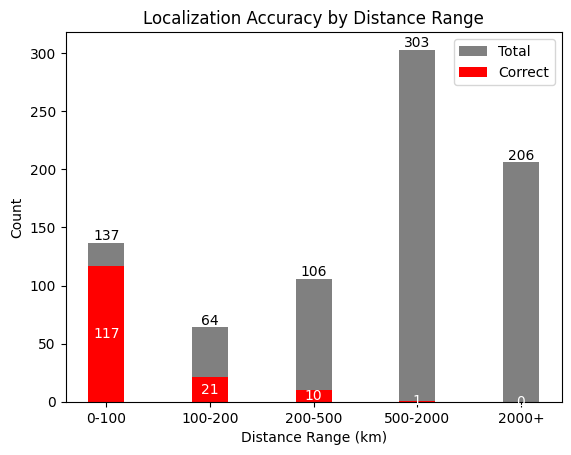

In [36]:
import json
import statistics
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

with open(user_loc_path, 'r') as f:
    data = json.load(f)

# Initialize variables for analysis
total_entries = 0
correct_entries = 0
distance_list = []

# Define distance ranges and their counts
distance_ranges = {
    "0-100": {"total": 0, "correct": 0, "locations": []},
    "100-200": {"total": 0, "correct": 0, "locations": []},
    "200-500": {"total": 0, "correct": 0, "locations": []},
    "500-2000": {"total": 0, "correct": 0, "locations": []},
    "2000+": {"total": 0, "correct": 0, "locations": []}
}


# Dictionary to store state-wise accuracy
state_accuracy = defaultdict(lambda: {"total": 0, "correct": 0})


# Process each entry in the data
for entry in data:
    ip, error_km, pre_coords, real_coords, pre_address, real_address = entry
    
    # Skip entries where any of the necessary fields are null
    if None in [error_km, pre_coords, real_coords, pre_address, real_address]:
        continue
    
    total_entries += 1

    # Extract state from real address
    try:
        state = real_address.split('/')[0].strip()
        state_accuracy[state]["total"] += 1
    except IndexError:
        continue
    
    # Check if addresses match
    if pre_address == real_address:
        correct_entries += 1
        if state in state_accuracy:
            state_accuracy[state]["correct"] += 1
    
    # Record the error distance
    distance_list.append(error_km)
    
    # Determine which distance range this entry falls into

    if 0 <= error_km < 100:
        distance_ranges["0-100"]["total"] += 1
        if pre_address == real_address:
            distance_ranges["0-100"]["correct"] += 1
        distance_ranges["0-100"]["locations"].append((real_address, real_coords))
    elif 100 <= error_km < 200:
        distance_ranges["100-200"]["total"] += 1
        if pre_address == real_address:
            distance_ranges["100-200"]["correct"] += 1
        distance_ranges["100-200"]["locations"].append((real_address, real_coords))
    elif 200 <= error_km < 500:
        distance_ranges["200-500"]["total"] += 1
        if pre_address == real_address:
            distance_ranges["200-500"]["correct"] += 1
        distance_ranges["200-500"]["locations"].append((real_address, real_coords))
    elif 500 <= error_km < 2000:
        distance_ranges["500-2000"]["total"] += 1
        if pre_address == real_address:
            distance_ranges["500-2000"]["correct"] += 1
        distance_ranges["500-2000"]["locations"].append((real_address, real_coords))
    else:
        distance_ranges["2000+"]["total"] += 1
        if pre_address == real_address:
            distance_ranges["2000+"]["correct"] += 1
        distance_ranges["2000+"]["locations"].append((real_address, real_coords))

# Calculate accuracy rate
accuracy_rate = (correct_entries / total_entries) * 100 if total_entries > 0 else 0

# Calculate average and median of distances
average_distance = statistics.mean(distance_list) if distance_list else 0
median_distance = statistics.median(distance_list) if distance_list else 0

print(f"Accuracy Rate: {accuracy_rate:.2f}%")
print(f"Average Distance Error: {average_distance:.2f} km")
print(f"Median Distance Error: {median_distance:.2f} km")

# Prepare data for plotting
labels = list(distance_ranges.keys())
total_counts = [d['total'] for d in distance_ranges.values()]
correct_counts = [d['correct'] for d in distance_ranges.values()]

# Plotting the bar chart
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots()
bars_total = ax.bar(x, total_counts, width, label='Total', color='gray')
bars_correct = ax.bar(x, correct_counts, width, label='Correct', color='red')

# Add labels on top of bars
def add_labels(bars, inside=False):
    for bar in bars:
        yval = bar.get_height()
        xval = bar.get_x() + bar.get_width() / 2
        if inside:
            ax.text(xval, bar.get_y() + yval / 2, round(yval), ha='center', va='center', color='white')
        else:
            ax.text(xval, bar.get_y() + yval, round(yval), ha='center', va='bottom')

add_labels(bars_total, inside=False)
add_labels(bars_correct, inside=True)

ax.set_xlabel('Distance Range (km)')
ax.set_ylabel('Count')
ax.set_title('Localization Accuracy by Distance Range')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


In [37]:
# Extract and display features for 0-100 km and 100-200 km ranges
from collections import defaultdict, Counter

def extract_features(range_data):
    locations = range_data["locations"]
    city_counter = Counter(address.split('/')[0].strip() for address, coords in locations)
    return city_counter

range_0_100_cities = extract_features(distance_ranges["0-100"])
range_100_200_cities = extract_features(distance_ranges["100-200"])

print("\nCities in 0-100 km range:")
for city, count in range_0_100_cities.items():
    print(f"{city}: {count}")

print("\nCities in 100-200 km range:")
for city, count in range_100_200_cities.items():
    print(f"{city}: {count}")


Cities in 0-100 km range:
新泽西州: 3
伊利诺伊州: 80
弗吉尼亚州: 12
纽约州: 20
佐治亚州: 17
得克萨斯州: 2
密苏里州: 1
犹他州: 1
佛罗里达州: 1

Cities in 100-200 km range:
纽约州: 20
北卡罗来纳州: 3
弗吉尼亚州: 10
伊利诺伊州: 12
康涅狄格州: 1
佛罗里达州: 1
马里兰州: 3
新泽西州: 1
得克萨斯州: 6
俄亥俄州: 1
宾夕法尼亚: 1
佐治亚州: 2
肯塔基州: 2
印第安纳州: 1


In [39]:
print("\nState-wise Accuracy Rates Sorted by Accuracy:")
sorted_state_accuracies = sorted(state_accuracy.items(), key=lambda item: (item[1]["correct"] / item[1]["total"]) if item[1]["total"] > 0 else 0, reverse=True)

for state, counts in sorted_state_accuracies:
    total = counts["total"]
    correct = counts["correct"]
    accuracy_rate = (correct / total) * 100 if total > 0 else 0
    print(f"{state}: {accuracy_rate:.2f}% (Total: {total}, Correct: {correct})")


State-wise Accuracy Rates Sorted by Accuracy:
华盛顿州: 100.00% (Total: 1, Correct: 1)
佐治亚州: 90.48% (Total: 21, Correct: 19)
伊利诺伊州: 86.73% (Total: 113, Correct: 98)
佛罗里达州: 50.00% (Total: 4, Correct: 2)
纽约州: 23.42% (Total: 111, Correct: 26)
俄亥俄州: 20.00% (Total: 5, Correct: 1)
宾夕法尼亚: 16.67% (Total: 6, Correct: 1)
密苏里州: 12.50% (Total: 8, Correct: 1)
新泽西州: 0.00% (Total: 11, Correct: 0)
弗吉尼亚州: 0.00% (Total: 65, Correct: 0)
加利福尼亚州: 0.00% (Total: 231, Correct: 0)
北卡罗来纳州: 0.00% (Total: 48, Correct: 0)
犹他州: 0.00% (Total: 5, Correct: 0)
得克萨斯州: 0.00% (Total: 110, Correct: 0)
堪萨斯州: 0.00% (Total: 2, Correct: 0)
阿肯色州: 0.00% (Total: 2, Correct: 0)
亚利桑那州: 0.00% (Total: 23, Correct: 0)
亚拉巴马州: 0.00% (Total: 4, Correct: 0)
康涅狄格州: 0.00% (Total: 2, Correct: 0)
内华达州: 0.00% (Total: 4, Correct: 0)
马里兰州: 0.00% (Total: 6, Correct: 0)
西弗吉尼亚州: 0.00% (Total: 2, Correct: 0)
密歇根州: 0.00% (Total: 4, Correct: 0)
田纳西州: 0.00% (Total: 3, Correct: 0)
爱达荷州: 0.00% (Total: 1, Correct: 0)
内布拉斯加州: 0.00% (Total: 1, Correct: 0)
肯塔基州